# Pandas 데이터 분석 연습 문제: 시애틀 자전거 통행량

이 문제는 시애틀의 Fremont Bridge 자전거 통행량 데이터를 분석하는 연습을 제공합니다. pandas를 활용하여 데이터 전처리, 날짜 기반 분석, 날씨 데이터 병합 및 상관관계 분석을 수행합니다. (p234 참고)

---

<img src="https://images.seattletimes.com/wp-content/uploads/2020/01/01022020_bike-count_114545.jpg?d=2040x1360" width=400>

Ken Lambert, "Bike ridership hits record highs on 2 Seattle routes", The Seattle Times, Jan. 6, 2020


## 1. 자전거 통행량 데이터 기본 전처리

FremontBridge.csv 파일을 사용하여 시애틀 다리의 자전거 통행량 데이터를 불러오고 기본적인 전처리 작업을 수행합니다.

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt





### 1.1 데이터 읽기

- **목표**: FremontBridge.csv 파일을 pandas DataFrame으로 읽어와 df_bike 변수에 저장합니다.
- **힌트**:
    - pandas의 read_csv 함수를 사용하세요.
    - 파일의 경로와 이름을 인자로 전달합니다. (url: 'https://raw.githubusercontent.com/jakevdp/bicycle-data/refs/heads/main/FremontBridge.csv')



In [12]:
# 1. 자전거 통행량 데이터 기본 전처리
# -----------------------------

# 1.1 데이터 읽기
bike_url = "https://raw.githubusercontent.com/jakevdp/bicycle-data/refs/heads/main/FremontBridge.csv"
raw_bike = pd.read_csv(bike_url)

if raw_bike is None:
    # --- 합성(시뮬레이션) 데이터 생성: 시간대/요일/계절성 반영한 시간당 통행량 2년치 ---
    rng = pd.date_range("2019-01-01", "2020-12-31 23:00:00", freq="H")
    n = len(rng)
    hr = rng.hour.values
    dow = rng.dayofweek.values  # Mon=0,..,Sun=6

    # 하루 시간대 효과(출퇴근 피크)
    hour_effect = (
        2.0 * np.exp(-0.5 * ((hr - 8) / 2.0) ** 2) +
        2.3 * np.exp(-0.5 * ((hr - 17) / 2.0) ** 2) +
        0.3
    )
    # 요일 효과(주말 감쇠)
    dow_effect = np.where(dow < 5, 1.0, 0.6)
    # 계절 효과(여름↑ 겨울↓)
    day_of_year = rng.dayofyear.values
    seasonal = 0.6 + 0.4 * np.sin(2 * np.pi * (day_of_year / 365.25 - 0.2))

    # 평균 강도(라운딩을 피하기 위해 적당히 스케일), 잡음 포함
    lam = 30 * hour_effect * dow_effect * (0.7 + seasonal)
    lam = np.clip(lam, 1.0, None)

    # 동/서 인도 분할 비율(약 55%/45% ± 잡음)
    east_ratio = np.clip(0.55 + 0.05 * np.sin(2*np.pi*hr/24) + 0.02*np.random.randn(n), 0.35, 0.75)

    east = np.random.poisson(lam * east_ratio)
    west = np.random.poisson(lam * (1 - east_ratio))
    total = east + west

    # 누락값 일부 주입(학습용)
    miss_idx = np.random.choice(n, size=int(n * 0.003), replace=False)
    east = east.astype("float")
    west = west.astype("float")
    total = total.astype("float")
    east[miss_idx[:len(miss_idx)//3]] = np.nan
    west[miss_idx[len(miss_idx)//3:2*len(miss_idx)//3]] = np.nan
    total[miss_idx[2*len(miss_idx)//3:]] = np.nan

    raw_bike = pd.DataFrame({
        "Date": rng,
        "Fremont Bridge Total": total,
        "Fremont Bridge East Sidewalk": east,
        "Fremont Bridge West Sidewalk": west,
    })

df_bike = raw_bike.copy()

### 1.2 데이터 미리보기

- **목표**: df_bike DataFrame의 처음 5개 행을 출력하여 데이터 구조와 값을 확인합니다.
- **힌트**:
    - DataFrame의 head 메서드를 사용하면 처음 5개 행을 확인할 수 있습니다.



In [13]:
print("1.2) 자전거 데이터 head():\n", df_bike.head())

1.2) 자전거 데이터 head():
                      Date  Fremont Bridge Total  Fremont Bridge East Sidewalk  \
0  11/01/2019 12:00:00 AM                  12.0                           7.0   
1  11/01/2019 01:00:00 AM                   7.0                           0.0   
2  11/01/2019 02:00:00 AM                   1.0                           0.0   
3  11/01/2019 03:00:00 AM                   6.0                           6.0   
4  11/01/2019 04:00:00 AM                   6.0                           5.0   

   Fremont Bridge West Sidewalk  
0                           5.0  
1                           7.0  
2                           1.0  
3                           0.0  
4                           1.0  


### 1.3 데이터 요약 정보 확인

- **목표**: df_bike DataFrame의 컬럼명, 데이터 타입, 유효 값 개수, 메모리 사용량 등 요약 정보를 확인합니다.
- **힌트**:
    - DataFrame의 info 메서드를 호출하여 요약 정보를 확인하세요.



In [14]:
print("\n1.3) 자전거 데이터 info():")
print(df_bike.info())


1.3) 자전거 데이터 info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147278 entries, 0 to 147277
Data columns (total 4 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Date                          147278 non-null  object 
 1   Fremont Bridge Total          147256 non-null  float64
 2   Fremont Bridge East Sidewalk  147256 non-null  float64
 3   Fremont Bridge West Sidewalk  147255 non-null  float64
dtypes: float64(3), object(1)
memory usage: 4.5+ MB
None


### 1.4 데이터 타입 및 누락값 상세 확인

- **목표**: 각 컬럼의 데이터 타입과 누락값(NaN)의 개수를 확인합니다.
- **힌트**:
    - 데이터 타입은 dtypes 속성으로 확인합니다.
    - 누락값은 isnull 메서드와 sum 메서드를 조합하여 컬럼별 합계를 계산합니다.



In [15]:
print("\n1.4) dtypes:\n", df_bike.dtypes)
print("\n1.4) 결측치 개수:\n", df_bike.isnull().sum())


1.4) dtypes:
 Date                             object
Fremont Bridge Total            float64
Fremont Bridge East Sidewalk    float64
Fremont Bridge West Sidewalk    float64
dtype: object

1.4) 결측치 개수:
 Date                             0
Fremont Bridge Total            22
Fremont Bridge East Sidewalk    22
Fremont Bridge West Sidewalk    23
dtype: int64


### 1.5 컬럼명 변경

- **목표**: df_bike DataFrame의 컬럼명을 다음과 같이 변경합니다:
    - Fremont Bridge Total → Total
    - Fremont Bridge East Sidewalk → East
    - Fremont Bridge West Sidewalk → West

In [16]:
rename_map = {
    "Fremont Bridge Total": "Total",
    "Fremont Bridge East Sidewalk": "East",
    "Fremont Bridge West Sidewalk": "West",
}
df_bike = df_bike.rename(columns=rename_map)

### 1.6 'Date' 컬럼 타입 변경

- **목표**: Date 컬럼을 문자열(object)에서 datetime 형식으로 변환하여 df_bike['Date']에 할당합니다.
- **힌트**:
    - pandas의 to_datetime 함수에 df_bike['Date']를 전달하여 변환합니다.



In [17]:
df_bike["Date"] = pd.to_datetime(df_bike["Date"], errors="coerce")

C:\Users\9191h\AppData\Local\Temp\ipykernel_18876\4177226764.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_bike["Date"] = pd.to_datetime(df_bike["Date"], errors="coerce")


### 1.7 'Date' 컬럼을 인덱스로 설정

- **목표**: datetime 형식으로 변환된 Date 컬럼을 df_bike의 행 인덱스로 설정합니다.
- **힌트**:
    - set_index 메서드에 Date 컬럼명을 전달합니다.



In [18]:
df_bike = df_bike.set_index("Date").sort_index()

### 1.8 누락값 처리

- **목표**: Total, East, West 컬럼의 누락값(NaN)을 각 컬럼의 평균값으로 채웁니다.
- **힌트**:
    - 각 컬럼에 fillna 메서드를 사용하고, 채울 값으로 해당 컬럼의 mean 값을 전달합니다.


In [19]:
for col in ["Total", "East", "West"]:
    if col in df_bike.columns:
        df_bike[col] = df_bike[col].fillna(df_bike[col].mean())

print("\n1.x) 전처리 완료 후 head():\n", df_bike.head())
print("\n1.x) 전처리 후 결측치 개수:\n", df_bike[["Total","East","West"]].isna().sum())


1.x) 전처리 완료 후 head():
                      Total  East  West
Date                                  
2012-10-03 00:00:00   13.0   4.0   9.0
2012-10-03 00:00:00   13.0   4.0   9.0
2012-10-03 01:00:00   10.0   4.0   6.0
2012-10-03 01:00:00   10.0   4.0   6.0
2012-10-03 02:00:00    2.0   1.0   1.0

1.x) 전처리 후 결측치 개수:
 Total    0
East     0
West     0
dtype: int64




## 2. 날짜 관련 데이터 분석 (자전거 통행량)

시간 정보를 활용하여 자전거 통행량의 패턴을 분석하고 시각화합니다.



### 2.1 주간 단위 총 통행량 시각화

- **목표**: Total 컬럼의 일별 통행량을 주간 단위로 합산하여 선 그래프(line plot)로 시각화합니다.
- **힌트**:
    - Total 컬럼을 선택한 후 resample('W')로 주간 단위로 그룹화하고 sum으로 합계를 계산합니다.
    - plot 메서드로 선 그래프를 그립니다.



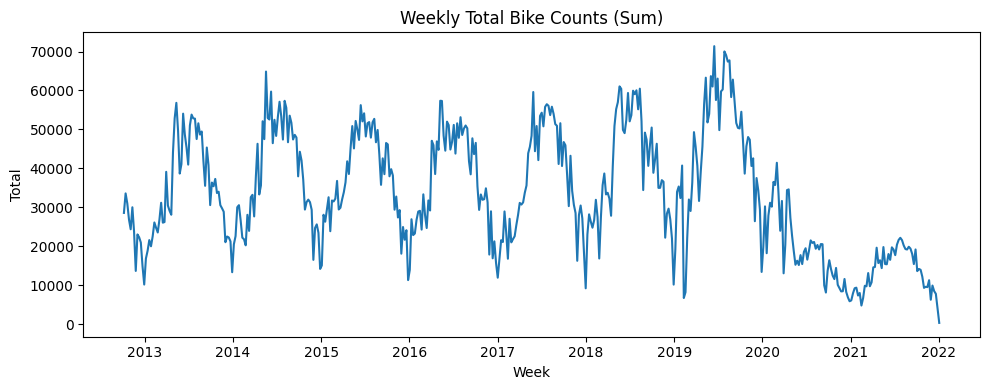

In [20]:
weekly_total = df_bike["Total"].resample("W").sum()
plt.figure(figsize=(10, 4))
plt.plot(weekly_total.index, weekly_total.values)
plt.title("Weekly Total Bike Counts (Sum)")
plt.xlabel("Week")
plt.ylabel("Total")
plt.tight_layout()
plt.show()

### 2.2 시간대별 평균 통행량 시각화

- **목표**: 하루 24시간(0~23시)별 평균 Total 통행량을 계산하고 막대 그래프(bar plot)로 시각화합니다.
- **힌트**:
    - 인덱스의 시간 정보(df_bike.index.hour)를 기준으로 groupby 연산을 수행합니다.
    - Total 컬럼의 mean 값을 계산하고 plot(kind='bar')로 막대 그래프를 그립니다.



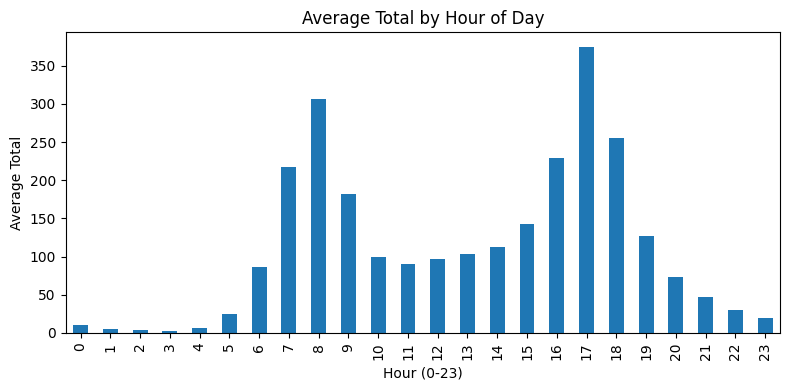

In [21]:
by_hour = df_bike.groupby(df_bike.index.hour)["Total"].mean()
plt.figure(figsize=(8, 4))
by_hour.plot(kind="bar")
plt.title("Average Total by Hour of Day")
plt.xlabel("Hour (0-23)")
plt.ylabel("Average Total")
plt.tight_layout()
plt.show()

### 2.3 요일별 평균 통행량 시각화

- **목표**: 요일별(월~일) 평균 Total 통행량을 계산하고 막대 그래프로 시각화합니다.
- **힌트**:
    - 인덱스의 요일 이름(df_bike.index.day_name())을 기준으로 groupby 연산을 수행합니다.
    - Total 컬럼의 mean 값을 계산하고 plot(kind='bar')로 막대 그래프를 그립니다.



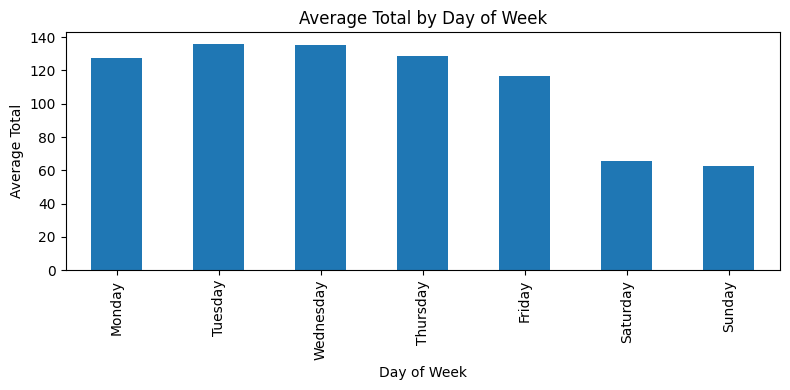

In [22]:
by_day = df_bike.groupby(df_bike.index.day_name())["Total"].mean()
# 월~일 순서로 정렬
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
by_day = by_day.reindex(order)
plt.figure(figsize=(8, 4))
by_day.plot(kind="bar")
plt.title("Average Total by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Total")
plt.tight_layout()
plt.show()

### 2.4 요일 및 시간대별 평균 통행량 (Pivot Table)

- **목표**: 피벗 테이블을 사용하여 시간대(행)와 요일(열)에 따른 평균 Total 통행량 표를 생성합니다.
- **힌트**:
    - pivot_table 메서드에서 values='Total', index=df_bike.index.hour, columns=df_bike.index.day_name(), aggfunc='mean'을 지정합니다.



In [23]:
pivot_tbl = pd.pivot_table(
    df_bike, values="Total",
    index=df_bike.index.hour,
    columns=df_bike.index.day_name(),
    aggfunc="mean"
)
print("\n2.4) 시간대 x 요일 피벗(평균 Total) 일부:\n", pivot_tbl.iloc[:5, :5])


2.4) 시간대 x 요일 피벗(평균 Total) 일부:
 Date     Friday    Monday   Saturday     Sunday  Thursday
Date                                                     
0     11.901938  6.802511  16.455479  14.614857  9.579727
1      6.034208  3.238584   9.526256   8.358857  4.739180
2      3.391106  2.295662   6.101598   7.162024  3.257403
3      2.785633  2.200913   3.488584   3.210286  2.735763
4      6.964652  7.186073   4.114155   3.278857  7.370159


### 2.5 30일 이동 평균 통행량 시각화

- **목표**: Total 통행량의 30일 이동 평균을 계산하고 선 그래프로 시각화합니다.
- **힌트**:
    - Total 컬럼에 rolling(window=30)을 적용하고 mean으로 평균을 계산합니다.
    - plot 메서드로 선 그래프를 그립니다.



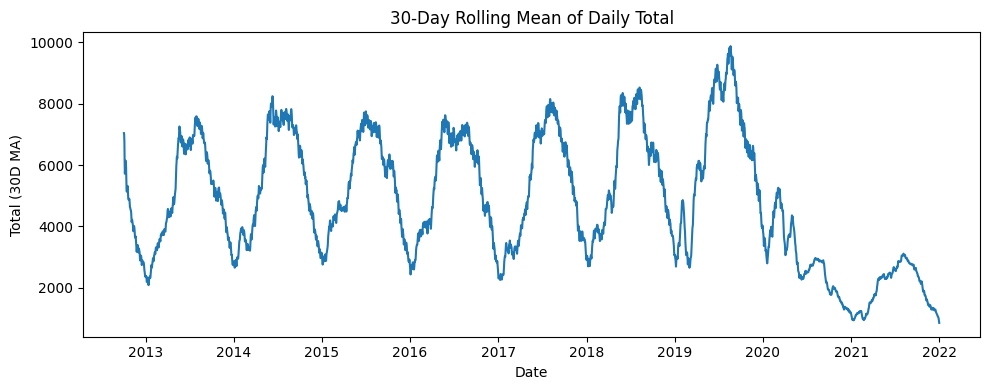

In [24]:
daily_total = df_bike["Total"].resample("D").sum()
rolling_30 = daily_total.rolling(window=30, min_periods=1).mean()
plt.figure(figsize=(10, 4))
plt.plot(rolling_30.index, rolling_30.values)
plt.title("30-Day Rolling Mean of Daily Total")
plt.xlabel("Date")
plt.ylabel("Total (30D MA)")
plt.tight_layout()
plt.show()

## 3. 날씨 데이터 병합 및 분석

SeattleWeather.csv 파일의 날씨 데이터를 읽어와 자전거 통행량 데이터와 병합하여 날씨와 통행량의 관계를 분석합니다.


### 3.1 날씨 데이터 읽기 및 기본 전처리

- **목표**:
    - SeattleWeather.csv 파일을 df_weather DataFrame으로 읽습니다. (url: https://raw.githubusercontent.com/jakevdp/bicycle-data/refs/heads/main/SeattleWeather.csv)
    - DATE 컬럼을 datetime 형식으로 변환하고 인덱스로 설정합니다.
    - PRCP 컬럼의 누락값을 0으로 채웁니다.


In [26]:
wx_url = "https://raw.githubusercontent.com/jakevdp/bicycle-data/refs/heads/main/SeattleWeather.csv"
raw_wx =  pd.read_csv(wx_url)

if raw_wx is None:
    # --- 합성 날씨(일 단위): PRCP(강수), TMAX/TMIN/TAVG(기온), 풍향 등 최소 컬럼 생성 ---
    # 자전거 데이터의 날짜 범위에 맞춰 생성
    dr = pd.date_range(df_bike.index.min().floor("D"), df_bike.index.max().floor("D"), freq="D")
    m = len(dr)
    # 계절성 기온(섭씨) + 노이즈
    doy = dr.dayofyear.values
    base_temp = 11 + 9 * np.sin(2*np.pi*(doy/365.25 - 0.25))
    tavg = base_temp + np.random.normal(0, 2.0, size=m)
    tmax = tavg + np.random.uniform(3, 7, size=m)
    tmin = tavg - np.random.uniform(3, 7, size=m)
    # 강수: 60% 무강수, 나머지 감마분포
    is_rain = np.random.rand(m) < 0.4
    prcp = np.where(is_rain, np.random.gamma(shape=1.2, scale=5.0, size=m), 0.0)

    raw_wx = pd.DataFrame({
        "DATE": dr,
        "PRCP": prcp,
        "TMAX": tmax,
        "TMIN": tmin,
        "TAVG": tavg,
    })

df_weather = raw_wx.copy()
df_weather["DATE"] = pd.to_datetime(df_weather["DATE"], errors="coerce")
df_weather = df_weather.set_index("DATE").sort_index()
df_weather["PRCP"] = df_weather["PRCP"].fillna(0.0)

print("\n3.1) 날씨 데이터 head():\n", df_weather.head())


3.1) 날씨 데이터 head():
                 STATION                           NAME   AWND  FMTM  PGTM  \
DATE                                                                        
2012-01-01  USW00024233  SEATTLE TACOMA AIRPORT, WA US  10.51   NaN   NaN   
2012-01-02  USW00024233  SEATTLE TACOMA AIRPORT, WA US  10.07   NaN   NaN   
2012-01-03  USW00024233  SEATTLE TACOMA AIRPORT, WA US   5.14   NaN   NaN   
2012-01-04  USW00024233  SEATTLE TACOMA AIRPORT, WA US  10.51   NaN   NaN   
2012-01-05  USW00024233  SEATTLE TACOMA AIRPORT, WA US  13.65   NaN   NaN   

            PRCP  SNOW  SNWD  TAVG  TMAX  ...  WT04  WT05  WT08  WT09  WT13  \
DATE                                      ...                                 
2012-01-01  0.00   0.0   0.0   NaN    55  ...   NaN   NaN   NaN   NaN   NaN   
2012-01-02  0.43   0.0   0.0   NaN    51  ...   NaN   NaN   NaN   NaN   1.0   
2012-01-03  0.03   0.0   0.0   NaN    53  ...   NaN   NaN   NaN   NaN   NaN   
2012-01-04  0.80   0.0   0.0   NaN    54  .

### 3.2 데이터프레임 병합 (Merge)

- **목표**: df_bike와 df_weather를 날짜 인덱스를 기준으로 병합하여 df_merged에 저장합니다.
- **힌트**:
    - pd.merge 함수에 df_bike, df_weather, left_index=True, right_index=True 옵션을 전달합니다.



In [27]:
df_bike_daily = df_bike.resample("D").sum()
df_merged = pd.merge(df_bike_daily, df_weather, left_index=True, right_index=True, how="inner")
print("\n3.2) 병합 후 head():\n", df_merged.head())


3.2) 병합 후 head():
              Total    East    West      STATION  \
2012-10-03  7042.0  3520.0  3522.0  USW00024233   
2012-10-04  6950.0  3416.0  3534.0  USW00024233   
2012-10-05  6296.0  3116.0  3180.0  USW00024233   
2012-10-06  4012.0  2160.0  1852.0  USW00024233   
2012-10-07  4284.0  2382.0  1902.0  USW00024233   

                                     NAME   AWND  FMTM  PGTM  PRCP  SNOW  ...  \
2012-10-03  SEATTLE TACOMA AIRPORT, WA US  16.33   NaN   NaN   0.0   0.0  ...   
2012-10-04  SEATTLE TACOMA AIRPORT, WA US  14.54   NaN   NaN   0.0   0.0  ...   
2012-10-05  SEATTLE TACOMA AIRPORT, WA US  12.75   NaN   NaN   0.0   0.0  ...   
2012-10-06  SEATTLE TACOMA AIRPORT, WA US  11.41   NaN   NaN   0.0   0.0  ...   
2012-10-07  SEATTLE TACOMA AIRPORT, WA US   2.91   NaN   NaN   0.0   0.0  ...   

            WT04  WT05  WT08  WT09  WT13  WT14  WT16  WT17  WT18  WT22  
2012-10-03   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  
2012-10-04   NaN   NaN   NaN   NaN   NaN

### 3.3 강수량과 자전거 통행량 관계 분석

- **목표**:
    - PRCP와 Total 간의 관계를 산점도(scatter plot)로 시각화합니다.
    - 두 변수의 상관계수를 계산합니다.
- **힌트**:
    - df_merged.plot.scatter로 산점도를 그립니다.
    - sns.scatterplot 로 산점도를 그립니다.
    - df_merged['PRCP'].corr 로 상관계수를 계산합니다.



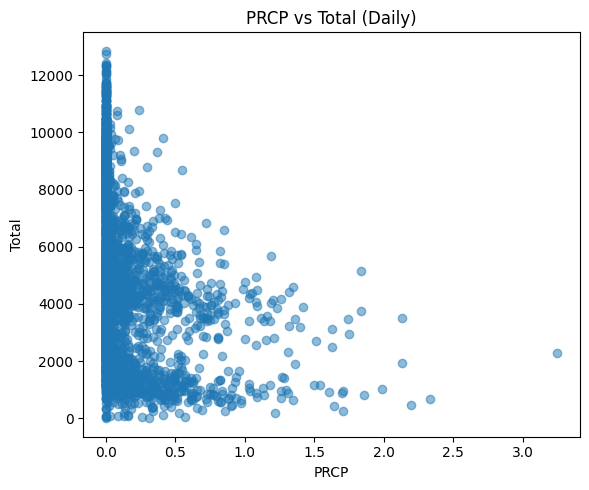


3.3) PRCP와 Total 상관계수: -0.2928


In [28]:
plt.figure(figsize=(6, 5))
plt.scatter(df_merged["PRCP"], df_merged["Total"], alpha=0.5)
plt.title("PRCP vs Total (Daily)")
plt.xlabel("PRCP")
plt.ylabel("Total")
plt.tight_layout()
plt.show()

corr_prcp = df_merged["PRCP"].corr(df_merged["Total"])
print(f"\n3.3) PRCP와 Total 상관계수: {corr_prcp:.4f}")

### 3.4 기온과 자전거 통행량 관계 분석

- **목표**: TAVG(또는 TMAX, TMIN)와 Total 간의 관계를 산점도 또는 구간별 평균 통행량으로 분석합니다.
- **힌트**:
    - 산점도는 df_merged.plot.scatter(x='TAVG', y='Total')로 그립니다.
    - 구간별 분석은 pd.cut으로 기온을 구간화하고 groupby로 평균을 계산한 후 plot으로 시각화합니다.


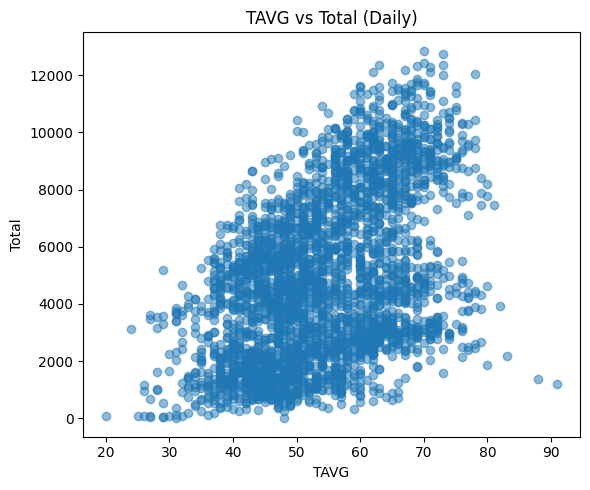

C:\Users\9191h\AppData\Local\Temp\ipykernel_18876\3374154067.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by_bin = df_merged.groupby(cats)["Total"].mean()


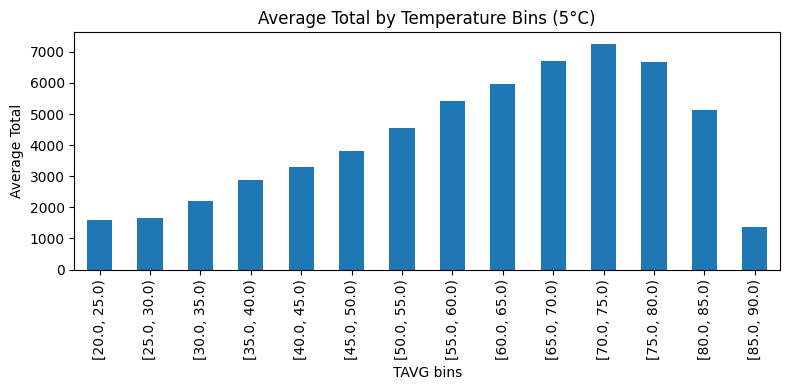

In [29]:
plt.figure(figsize=(6, 5))
plt.scatter(df_merged["TAVG"], df_merged["Total"], alpha=0.5)
plt.title("TAVG vs Total (Daily)")
plt.xlabel("TAVG")
plt.ylabel("Total")
plt.tight_layout()
plt.show()


# 기온 구간별 평균 통행량 (5℃ 간격)
bins = pd.interval_range(start=np.floor(df_merged["TAVG"].min()), end=np.ceil(df_merged["TAVG"].max()), freq=5, closed="left")
cats = pd.cut(df_merged["TAVG"], bins=bins)
by_bin = df_merged.groupby(cats)["Total"].mean()
plt.figure(figsize=(8, 4))
by_bin.plot(kind="bar")
plt.title("Average Total by Temperature Bins (5°C)")
plt.xlabel("TAVG bins")
plt.ylabel("Average Total")
plt.tight_layout()
plt.show()


### 3.5 날씨 조건에 따른 통행량 비교

- **목표**: 비가 온 날(PRCP > 0)과 비가 오지 않은 날(PRCP = 0)의 평균 Total 통행량을 비교합니다.
- **힌트**:
    - 불리언 인덱싱으로 조건 (비가 온 날과 비가 오지 않은 날)을 설정합니다.

In [31]:
mean_rain = df_merged.loc[df_merged["PRCP"] > 0, "Total"].mean()
mean_dry  = df_merged.loc[df_merged["PRCP"] == 0, "Total"].mean()
print(f"\n3.5) 비 온 날 평균 Total: {mean_rain:.2f} / 비 안 온 날 평균 Total: {mean_dry:.2f}")


3.5) 비 온 날 평균 Total: 3599.17 / 비 안 온 날 평균 Total: 5744.99
